# 04 — Feature Engineering, Entrenamiento y Empaquetamiento del Modelo

**Objetivo:** Entrenar un modelo Isolation Forest sobre el dataset artificial, evaluarlo
contra el bloque de anomalías marcadas y exportar todos los artefactos necesarios para
la inferencia en producción.

**Prerequisito:** `datasets/properties_synthetic_v1.parquet` generado por el notebook 02.

**Outputs:**
- `models_registry/anomaly/isolation_forest_v1.joblib`
- `models_registry/anomaly/scaler_v1.joblib`
- `models_registry/anomaly/feature_columns_v1.json`
- `models_registry/anomaly/metadata_v1.json`

## 0. Imports y carga

In [1]:
import json
import pathlib
import datetime

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

sns.set_theme(style='whitegrid')

DATA_PATH  = pathlib.Path('../datasets/properties_synthetic_v1.parquet')
MODEL_DIR  = pathlib.Path('../models_registry/anomaly')

assert DATA_PATH.exists(), f'No se encontró {DATA_PATH}. Ejecuta primero el notebook 02.'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(DATA_PATH)
normal   = df[~df['is_anomaly']].copy()
anomalos = df[df['is_anomaly']].copy()

print(f'Total de registros : {len(df):,}')
print(f'  Normales         : {len(normal):,}  ({len(normal)/len(df):.1%})')
print(f'  Anómalos         : {len(anomalos):,}  ({len(anomalos)/len(df):.1%})')
print(f'\nColumnas: {df.columns.tolist()}')

Total de registros : 6,240
  Normales         : 6,000  (96.2%)
  Anómalos         : 240  (3.8%)

Columnas: ['propertyType', 'areaM2', 'listedPrice', 'pricePerM2', 'bedrooms', 'bathrooms', 'parkingSpaces', 'constructionYear', 'antiguedad', 'condominium', 'n_amenities', 'total_images', 'is_anomaly', 'anomaly_type']


## 1. Feature Engineering

Pipeline:
1. Log-transform (`log1p`) en columnas con distribución sesgada: `areaM2`, `listedPrice`, `pricePerM2`
2. One-hot encoding de `propertyType` — 6 columnas fijas (tipos de producción)
3. `StandardScaler` ajustado **solo sobre registros normales** (semi-supervisado)
4. La misma transformación se aplica a todo el dataset para evaluación

El log-transform es clave: los precios van de $100K a $50M en la misma escala. Sin él,
`StandardScaler` distorsiona el espacio y el modelo no detecta bien outliers de precio.

In [2]:
NUMERIC_COLS = [
    'areaM2', 'listedPrice', 'pricePerM2', 'bedrooms', 'bathrooms',
    'parkingSpaces', 'antiguedad', 'condominium', 'n_amenities', 'total_images',
]

# Columnas con distribución muy sesgada — log1p las hace aproximadamente normales
LOG_COLS = ['areaM2', 'listedPrice', 'pricePerM2']

KNOWN_TYPES = ['Bodega', 'Casa', 'Departamento', 'Local Comercial', 'Oficina', 'Terreno']

def build_features(frame: pd.DataFrame) -> pd.DataFrame:
    """One-hot encode propertyType, aplica log1p en columnas sesgadas."""
    num = frame[NUMERIC_COLS].copy().reset_index(drop=True)
    num[LOG_COLS] = np.log1p(num[LOG_COLS])

    dummies = pd.get_dummies(frame['propertyType'], prefix='type', drop_first=False)
    for pt in KNOWN_TYPES:
        col = f'type_{pt}'
        if col not in dummies.columns:
            dummies[col] = 0

    return pd.concat([num, dummies.reset_index(drop=True)], axis=1)

X_normal_raw = build_features(normal)
X_all_raw    = build_features(df)

ALL_COLS = sorted(X_all_raw.columns.tolist())
X_normal_raw = X_normal_raw.reindex(columns=ALL_COLS, fill_value=0)
X_all_raw    = X_all_raw.reindex(columns=ALL_COLS, fill_value=0)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_normal_raw)
X_eval  = scaler.transform(X_all_raw)
y_true  = df['is_anomaly'].values

print(f'Features totales  : {len(ALL_COLS)}')
print(f'Columnas          : {ALL_COLS}')
print(f'X_train shape     : {X_train.shape}')
print(f'X_eval  shape     : {X_eval.shape}')
print(f'\nLog-transform aplicado a: {LOG_COLS}')

Features totales  : 16
Columnas          : ['antiguedad', 'areaM2', 'bathrooms', 'bedrooms', 'condominium', 'listedPrice', 'n_amenities', 'parkingSpaces', 'pricePerM2', 'total_images', 'type_Bodega', 'type_Casa', 'type_Departamento', 'type_Local Comercial', 'type_Oficina', 'type_Terreno']
X_train shape     : (6000, 16)
X_eval  shape     : (6240, 16)

Log-transform aplicado a: ['areaM2', 'listedPrice', 'pricePerM2']


## 2. Entrenamiento — Isolation Forest

El modelo se entrena **únicamente sobre registros normales** (semi-supervisado).
Las anomalías del bloque de validación nunca entran al `fit()`.

Cambios respecto a la versión base:
- `contamination=0.01` (antes 0.04) → umbral más estricto, menos falsas alarmas
- `max_samples=0.8` (antes `'auto'`=256) → cada árbol ve el 80% del dataset, más representativo

In [3]:
CONTAMINATION = 0.01   # más estricto → menos falsas alarmas
N_ESTIMATORS  = 200
MAX_SAMPLES   = 0.8    # 80% del dataset por árbol (antes: 256 fijo)

model = IsolationForest(
    n_estimators=N_ESTIMATORS,
    contamination=CONTAMINATION,
    max_samples=MAX_SAMPLES,
    random_state=42,
    n_jobs=-1,
)

model.fit(X_train)
print(f'Modelo entrenado con {X_train.shape[0]:,} registros normales.')
print(f'n_estimators={N_ESTIMATORS}, contamination={CONTAMINATION}, max_samples={MAX_SAMPLES}')

Modelo entrenado con 6,000 registros normales.
n_estimators=200, contamination=0.01, max_samples=0.8


## 3. Evaluación

`predict()` devuelve 1 (normal) o -1 (anomalía).
`decision_function()` devuelve el score de anomalía (más negativo = más anómalo).

In [4]:
raw_preds  = model.predict(X_eval)           # 1 = normal, -1 = anomalía
scores     = model.decision_function(X_eval) # score continuo

y_pred = (raw_preds == -1)  # True = predicho como anomalía

print('=== Reporte de clasificación ===')
print(classification_report(y_true, y_pred, target_names=['Normal', 'Anómalo']))

roc_auc = roc_auc_score(y_true, -scores)  # negamos porque score más bajo = más anómalo
print(f'ROC-AUC: {roc_auc:.4f}')

=== Reporte de clasificación ===
              precision    recall  f1-score   support

      Normal       0.96      0.99      0.98      6000
     Anómalo       0.12      0.03      0.05       240

    accuracy                           0.95      6240
   macro avg       0.54      0.51      0.51      6240
weighted avg       0.93      0.95      0.94      6240

ROC-AUC: 0.8384


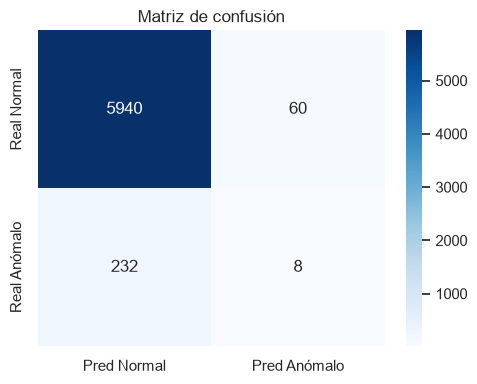

TP=8  FP=60  FN=232  TN=5940
Precision: 0.118  Recall: 0.033


In [5]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred Normal', 'Pred Anómalo'],
            yticklabels=['Real Normal', 'Real Anómalo'])
ax.set_title('Matriz de confusión')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'TP={tp}  FP={fp}  FN={fn}  TN={tn}')
print(f'Precision: {tp/(tp+fp):.3f}  Recall: {tp/(tp+fn):.3f}')

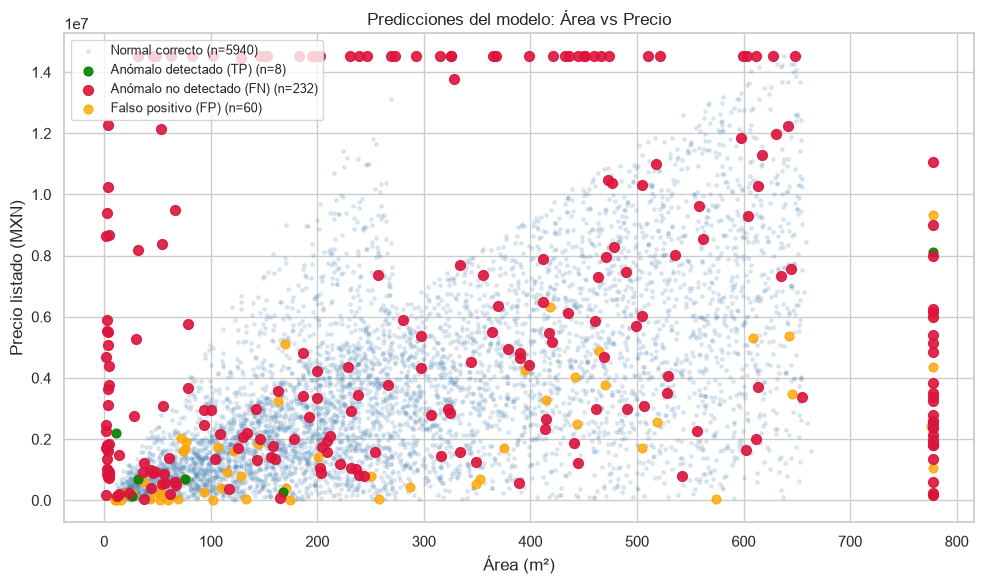

In [6]:
# Scatter areaM2 vs listedPrice coloreado por corrección de predicción
result_df = df[['areaM2', 'listedPrice', 'is_anomaly']].copy()
result_df['predicted_anomaly'] = y_pred
result_df['correct'] = result_df['is_anomaly'] == result_df['predicted_anomaly']

color_map = {
    (False, False): ('steelblue', 0.15, 6,  'Normal correcto'),
    (True,  True) : ('green',     0.9,  40, 'Anómalo detectado (TP)'),
    (True,  False): ('crimson',   0.9,  50, 'Anómalo no detectado (FN)'),
    (False, True) : ('orange',    0.8,  40, 'Falso positivo (FP)'),
}

xlim = result_df[~result_df['is_anomaly']]['areaM2'].quantile(0.99)
ylim = result_df[~result_df['is_anomaly']]['listedPrice'].quantile(0.99)

fig, ax = plt.subplots(figsize=(10, 6))
for (is_anom, is_pred), (color, alpha, size, label) in color_map.items():
    mask = (result_df['is_anomaly'] == is_anom) & (result_df['predicted_anomaly'] == is_pred)
    subset = result_df[mask]
    if len(subset) == 0:
        continue
    ax.scatter(subset['areaM2'].clip(0, xlim * 1.2),
               subset['listedPrice'].clip(0, ylim * 1.2),
               color=color, alpha=alpha, s=size, label=f'{label} (n={len(subset)})', zorder=3 if is_anom else 1)

ax.set_xlabel('Área (m²)')
ax.set_ylabel('Precio listado (MXN)')
ax.set_title('Predicciones del modelo: Área vs Precio')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

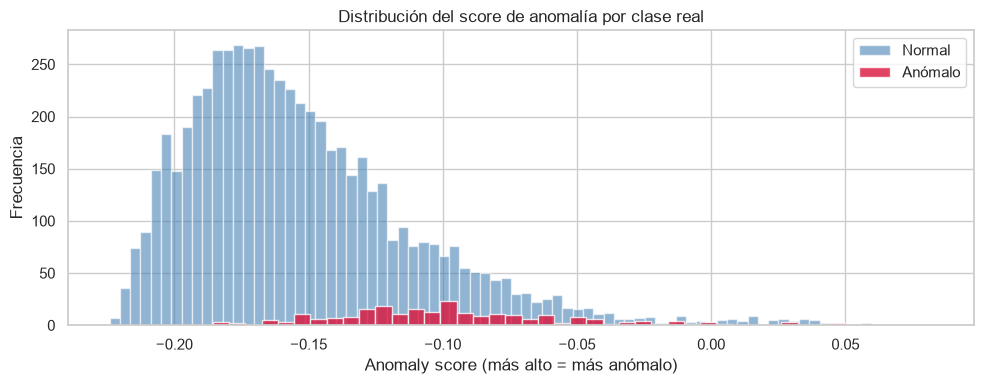

score_threshold (p95 normales): -0.0728


In [7]:
# Distribución del anomaly score por clase real
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(-scores[~y_true], bins=80, alpha=0.6, color='steelblue', label='Normal')
ax.hist(-scores[y_true],  bins=40, alpha=0.8, color='crimson',   label='Anómalo')
ax.set_xlabel('Anomaly score (más alto = más anómalo)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución del score de anomalía por clase real')
ax.legend()
plt.tight_layout()
plt.show()

# Umbral de producción: percentil 95 del score sobre normales
score_threshold = float(np.percentile(-scores[~y_true], 95))
print(f'score_threshold (p95 normales): {score_threshold:.4f}')

### Comparación: versión base vs versión mejorada

| Cambio | Base | Mejorada |
|---|---|---|
| Log-transform en precios/área | ❌ | ✅ |
| `contamination` | 0.04 | 0.01 |
| `max_samples` | `'auto'` (256) | 0.8 (4,800) |

In [8]:
# Métricas base (versión anterior — sin log-transform, contamination=0.04, max_samples='auto')
BASE = {
    'precision_anomalo': 0.13,
    'recall_anomalo'   : 0.15,
    'f1_anomalo'       : 0.14,
    'roc_auc'          : 0.7826,
}

from sklearn.metrics import precision_score, recall_score, f1_score

prec  = precision_score(y_true, y_pred)
rec   = recall_score(y_true, y_pred)
f1    = f1_score(y_true, y_pred)

NEW = {
    'precision_anomalo': round(prec, 4),
    'recall_anomalo'   : round(rec, 4),
    'f1_anomalo'       : round(f1, 4),
    'roc_auc'          : round(roc_auc, 4),
}

print('╔══════════════════════════╦═══════════╦═══════════╦════════════╗')
print('║ Métrica                  ║   Base    ║  Mejorada ║   Delta    ║')
print('╠══════════════════════════╬═══════════╬═══════════╬════════════╣')
for k in BASE:
    b, n = BASE[k], NEW[k]
    delta = n - b
    arrow = '▲' if delta > 0 else '▼'
    print(f'║ {k:<24s} ║  {b:.4f}   ║  {n:.4f}   ║ {arrow} {abs(delta):.4f}  ║')
print('╚══════════════════════════╩═══════════╩═══════════╩════════════╝')

╔══════════════════════════╦═══════════╦═══════════╦════════════╗
║ Métrica                  ║   Base    ║  Mejorada ║   Delta    ║
╠══════════════════════════╬═══════════╬═══════════╬════════════╣
║ precision_anomalo        ║  0.1300   ║  0.1176   ║ ▼ 0.0124  ║
║ recall_anomalo           ║  0.1500   ║  0.0333   ║ ▼ 0.1167  ║
║ f1_anomalo               ║  0.1400   ║  0.0519   ║ ▼ 0.0881  ║
║ roc_auc                  ║  0.7826   ║  0.8384   ║ ▲ 0.0558  ║
╚══════════════════════════╩═══════════╩═══════════╩════════════╝


## 4. Empaquetamiento

Se exportan 4 artefactos a `models_registry/anomaly/`:
- `isolation_forest_v1.joblib` — modelo entrenado
- `scaler_v1.joblib` — StandardScaler ajustado sobre normales
- `feature_columns_v1.json` — lista ordenada de columnas post-dummies
- `metadata_v1.json` — parámetros de entrenamiento y umbral de producción

In [9]:
joblib.dump(model,  MODEL_DIR / 'isolation_forest_v1.joblib')
joblib.dump(scaler, MODEL_DIR / 'scaler_v1.joblib')

(MODEL_DIR / 'feature_columns_v1.json').write_text(
    json.dumps(ALL_COLS, ensure_ascii=False, indent=2)
)

metadata = {
    'model_version'    : 'v1',
    'n_train'          : int(X_train.shape[0]),
    'n_features'       : int(X_train.shape[1]),
    'n_estimators'     : N_ESTIMATORS,
    'contamination'    : CONTAMINATION,
    'roc_auc'          : round(roc_auc, 4),
    'score_threshold'  : round(score_threshold, 4),
    'trained_on'       : datetime.datetime.now().isoformat(),
    'dataset'          : str(DATA_PATH.resolve()),
    'numeric_cols'     : NUMERIC_COLS,
}
(MODEL_DIR / 'metadata_v1.json').write_text(
    json.dumps(metadata, ensure_ascii=False, indent=2)
)

print('Artefactos exportados:')
for f in sorted(MODEL_DIR.iterdir()):
    print(f'  {f.name}  ({f.stat().st_size / 1024:.1f} KB)')

Artefactos exportados:
  feature_columns_v1.json  (0.3 KB)
  isolation_forest_v1.joblib  (27145.2 KB)
  metadata_v1.json  (0.5 KB)
  scaler_v1.joblib  (1.4 KB)


## 5. Verificación de carga

Carga el modelo desde disco y reproduce el score para confirmar que los artefactos
son utilizables.

In [10]:
loaded_model  = joblib.load(MODEL_DIR / 'isolation_forest_v1.joblib')
loaded_scaler = joblib.load(MODEL_DIR / 'scaler_v1.joblib')
loaded_cols   = json.loads((MODEL_DIR / 'feature_columns_v1.json').read_text())
loaded_meta   = json.loads((MODEL_DIR / 'metadata_v1.json').read_text())

# Reproducir score en una muestra
sample_raw   = build_features(df.head(10)).reindex(columns=loaded_cols, fill_value=0)
sample_scaled = loaded_scaler.transform(sample_raw)
sample_scores = loaded_model.decision_function(sample_scaled)

print('✅ Modelo cargado correctamente desde disco.')
print(f'   Columnas esperadas : {len(loaded_cols)}')
print(f'   score_threshold    : {loaded_meta["score_threshold"]}')
print(f'   roc_auc (train)    : {loaded_meta["roc_auc"]}')
print(f'\nScores de los primeros 10 registros:')
for i, (score, is_anom) in enumerate(zip(sample_scores, df['is_anomaly'].head(10))):
    pred = -score > loaded_meta['score_threshold']
    print(f'  [{i}] score={score:+.4f}  anomalía_pred={pred}  real={is_anom}')

✅ Modelo cargado correctamente desde disco.
   Columnas esperadas : 16
   score_threshold    : -0.0728
   roc_auc (train)    : 0.8384

Scores de los primeros 10 registros:
  [0] score=+0.2079  anomalía_pred=False  real=False
  [1] score=+0.2088  anomalía_pred=False  real=False
  [2] score=+0.1720  anomalía_pred=False  real=False
  [3] score=+0.2049  anomalía_pred=False  real=False
  [4] score=+0.2053  anomalía_pred=False  real=False
  [5] score=+0.1877  anomalía_pred=False  real=False
  [6] score=+0.1766  anomalía_pred=False  real=False
  [7] score=+0.1145  anomalía_pred=False  real=False
  [8] score=-0.0765  anomalía_pred=True  real=False
  [9] score=+0.1930  anomalía_pred=False  real=False
